In [1]:
!pip install jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.5 MB/s eta 0:00:00


In [2]:
# https://www.kaggle.com/competitions/autocorrect-aicc-round-1-2/overview

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence, unpad_sequence
from tqdm.auto import tqdm
import jiwer
from sklearn.model_selection import train_test_split
from IPython.display import clear_output

In [3]:
train = pd.read_csv("/kaggle/input/competitions/autocorrect-aicc-round-1-2/train.csv")
test = pd.read_csv("/kaggle/input/competitions/autocorrect-aicc-round-1-2/test.csv")

train.shape, test.shape

((10571, 2), (2643, 2))

In [4]:
train.head()

,text,misspell
0,The expansion of rugby in the first half of t...,ihe expansion wi rught in t=e first half of t...
1,In November 1999 IBM scientists demonstrated ...,am No vekbee1999 IBM scientists denljstfwtwd ...
2,Andrew was promoted to sergeant the day after...,Anrrew waspro moted to sergeant ohe d ayagter...
3,Welsh National Opera ( WNO ) ( Welsh : Opera ...,Welsh natitnal Opwra ( wno ) ( Qelsh : Opera ...
4,The New Zealand Mounted Rifles Brigade had mo...,toe N ewAsakand Mounted rufles brigate had mo...


In [5]:
class Vocabulary:
    def __init__(self, texts, pad_token='<PAD>'):
        self.tokens = self._define_tokens(texts, pad_token)
        self.id2token = {i: ch for i, ch in enumerate(self.tokens)}
        self.token2id = {ch: i for i, ch in self.id2token.items()}

        self.pad_token = pad_token
        self.pad_id = self.token2id[pad_token]

    def _define_tokens(self, texts, pad_token):
        tokens = set()
        for text in texts:
            tokens.update(text)
        return [pad_token] + sorted(list(tokens))

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        return self.id2token[idx]
    
    def encode(self, text):
        return [self.token2id[token] for token in text]

    def decode(self, ids):
        return ''.join([self.id2token[id] for id in ids])

vocab = Vocabulary(train['text'].tolist() + train['misspell'].tolist() + test['misspell'].tolist())
len(vocab)

95

In [6]:
train['text'][4], len(train['text'][4])

(" The New Zealand Mounted Rifles Brigade had moved out at dawn , followed by the 5th Mounted Brigade without ambulance support , as the New Zealand Field Ambulance had not returned from Romani and the 5th Mounted Field Ambulance had not yet arrived . Fortunately , casualties were light , and both ambulances arrived in the evening . The 3rd Light Horse Field Ambulance , had formed a dressing station at Bir Nagid to the south of Romani , treating wounded from 3rd Light Horse Brigade 's engagement at Bir el Hamisah , a convoy brought in wounded Ottomans from a hod to the south of Romani , and 150 cases of heat exhaustion from infantry in the 42nd Division were treated during the day . \n",
 691)

In [7]:
train['misspell'][4], len(train['misspell'][4])

(" toe N ewAsakand Mounted rufles brigate had moved out at dawn , clllosed bu the 5th mounted brigate without ambulance Supoort , as tje hew Zealand Field Ambulance jad not returned fgom Ronwni ind the 5th Mounted fiels qmbilance had nor yet arrivr\\ .Fodtynate lg , casualties a erelight , and ioth ambulances ar rivr\\st the Evering .T he 3rd Light hirse filed Ambulance , had formed a dressing station at bit Nagid to ere south of rpmwni , greating  woundedirom 3rd Tight hoese brigate 's engagement  ayBir el Hamixwb , y convoy brought in wounded Ottomzne from e hod to the south of Romani , fod 150 cases me heat exhaustion from infantry in the 42nd divisuon oere treated diring vee day . \n",
 691)

In [8]:
(train['text'].map(lambda x: len(x)) == train['misspell'].map(lambda x: len(x))).mean()

np.float64(1.0)

In [9]:
train['text'].map(lambda x: len(x)).max(), train['text'].map(lambda x: len(x)).min()

(3387, 101)

In [10]:
train, valid = train_test_split(train, test_size=0.1, random_state=41)
train, valid = train.reset_index(drop=True), valid.reset_index(drop=True)

train.shape, valid.shape

((9513, 2), (1058, 2))

In [11]:
class AutoCorrectDataset(Dataset):
    def __init__(self, vocab, df):
        self.vocab = vocab
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        misspell = self.df['misspell'][idx]
        misspell = self.vocab.encode(misspell)
        misspell = torch.LongTensor(misspell)
        if 'text' not in self.df.columns:
            return misspell, self.df['misspell'][idx]
        text = self.df['text'][idx]
        text = self.vocab.encode(text)
        text = torch.LongTensor(text)
        return misspell, text, self.df['misspell'][idx], self.df['text'][idx]

def make_collate_fn(pad_id):
    def collate_fn(batch):
        misspell_tensors, text_tensors, misspells, texts = zip(*batch)
        lengths = torch.tensor([len(t) for t in misspell_tensors])
        max_len = max(lengths)
        misspell_tensors = pad_sequence(misspell_tensors, batch_first=True, padding_value=pad_id)
        text_tensors = pad_sequence(text_tensors, batch_first=True, padding_value=pad_id)
        return misspell_tensors, text_tensors, misspells, texts, lengths
    return collate_fn
    

train_ds = AutoCorrectDataset(vocab, train)
valid_ds = AutoCorrectDataset(vocab, valid)
test_ds = AutoCorrectDataset(vocab, test)

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, collate_fn=make_collate_fn(vocab.pad_id), shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, collate_fn=make_collate_fn(vocab.pad_id), shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

len(train_loader), len(valid_loader), len(test_loader)

(595, 67, 2643)

In [12]:
class AutoCorrectModel(nn.Module):
    def __init__(self, vocab=vocab, hidden_size=128, dropout=0.0, bidirectional=True, num_layers=1):
        super().__init__()
        self.vocab = vocab
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        
        self.emb = nn.Embedding(len(vocab), hidden_size, vocab.pad_id)

        self.rnn = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True, bidirectional=bidirectional, dropout=dropout)
        
        self.head = nn.Sequential(
            nn.Linear(hidden_size*(2 if bidirectional else 1), len(vocab))
        )

    def forward(self, x, lengths):
        x = self.emb(x)
        x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(x)
        out, lengths = pad_packed_sequence(out, batch_first=True, padding_value=self.vocab.pad_id)
        return self.head(out), lengths

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
def train_one_epoch(model, optimizer, criterion, train_loader, vocab, device):
    model.train()
    total, rloss, rcer = 0, 0, 0
    for X, y, misspells, texts, lengths in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        X, y = X.to(device), y.to(device)
        output, lengths = model(X, lengths)
        loss = criterion(output.reshape(-1, output.shape[-1]), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = len(X)
        total += batch_size
        rloss += batch_size * loss.item()
        output = unpad_sequence(output, lengths, batch_first=True)
        pred_indices = [output[i].argmax(-1) for i in range(batch_size)]
        pred_texts = [vocab.decode(pred_indices[i].tolist()) for i in range(batch_size)]
        rcer += sum(jiwer.cer(text, pred_text) for text, pred_text in zip(texts, pred_texts))
        cur_loss = rloss / total
        cur_cer = rcer / total
        pbar.set_postfix({'loss': f'{cur_loss:.6f}', 'cer': f'{cur_cer:.6f}'})
        
    return cur_loss, cur_cer

@torch.inference_mode()
def valid_one_epoch(model, criterion, valid_loader, vocab, device):
    model.eval()
    total, rloss, rcer = 0, 0, 0
    for X, y, misspells, texts, lengths in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        X, y = X.to(device).squeeze(0), y.to(device).squeeze(0)
        output, lengths = model(X, lengths)
        loss = criterion(output.reshape(-1, output.shape[-1]), y.reshape(-1))

        batch_size = len(X)
        total += batch_size
        rloss += batch_size * loss.item()
        output = unpad_sequence(output, lengths, batch_first=True)
        pred_indices = [output[i].argmax(-1) for i in range(batch_size)]
        pred_texts = [vocab.decode(pred_indices[i].tolist()) for i in range(batch_size)]
        rcer += sum(jiwer.cer(text, pred_text) for text, pred_text in zip(texts, pred_texts))
        cur_loss = rloss / total
        cur_cer = rcer / total
        pbar.set_postfix({'loss': f'{cur_loss:.6f}', 'cer': f'{cur_cer:.6f}'})

    return cur_loss, cur_cer

def plot_progress(history, plot_title):
    clear_output(wait=True)
    plt.figure(figsize=(15, 5))
    plt.suptitle(plot_title)

    epochs = len(history['train_loss'])
    epoch_x = np.arange(1, epochs+1)
    
    plt.subplot(1, 2, 1)
    plt.plot(epoch_x, history['train_loss'], label='train')
    plt.plot(epoch_x, history['valid_loss'], label='valid')
    plt.legend()
    plt.title('Losses')
    plt.xlabel('epoch')
    plt.ylabel('loss')

    plt.subplot(1, 2, 2)
    plt.plot(epoch_x, history['train_cer'], label='train')
    plt.plot(epoch_x, history['valid_cer'], label='valid')
    plt.legend()
    plt.title('CERs')
    plt.xlabel('epoch')
    plt.ylabel('cer')

    plt.tight_layout()
    plt.show()
    
def fit(model, optimizer, scheduler, criterion, train_loader, valid_loader, vocab, device, epochs, history=None):
    if not history:
        history = {
            'train_loss': [],
            'train_cer': [],
            'valid_loss': [],
            'valid_cer': []
        }

    for epoch in range(epochs):
        tloss, tcer = train_one_epoch(model, optimizer, criterion, train_loader, vocab, device)
        vloss, vcer = valid_one_epoch(model, criterion, valid_loader, vocab, device)

        history['train_loss'].append(tloss)
        history['train_cer'].append(tcer)
        history['valid_loss'].append(vloss)
        history['valid_cer'].append(vcer)

        plot_progress(history, f'Epoch: {epoch+1}/{epochs}' + '' if scheduler is None else  f' | LR: {scheduler.get_last_lr()[0]:.6f}')
        if scheduler is not None:
            scheduler.step()
        
    return history

In [15]:
epochs = 10

model = AutoCorrectModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
scheduler = None
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_id)
history = None

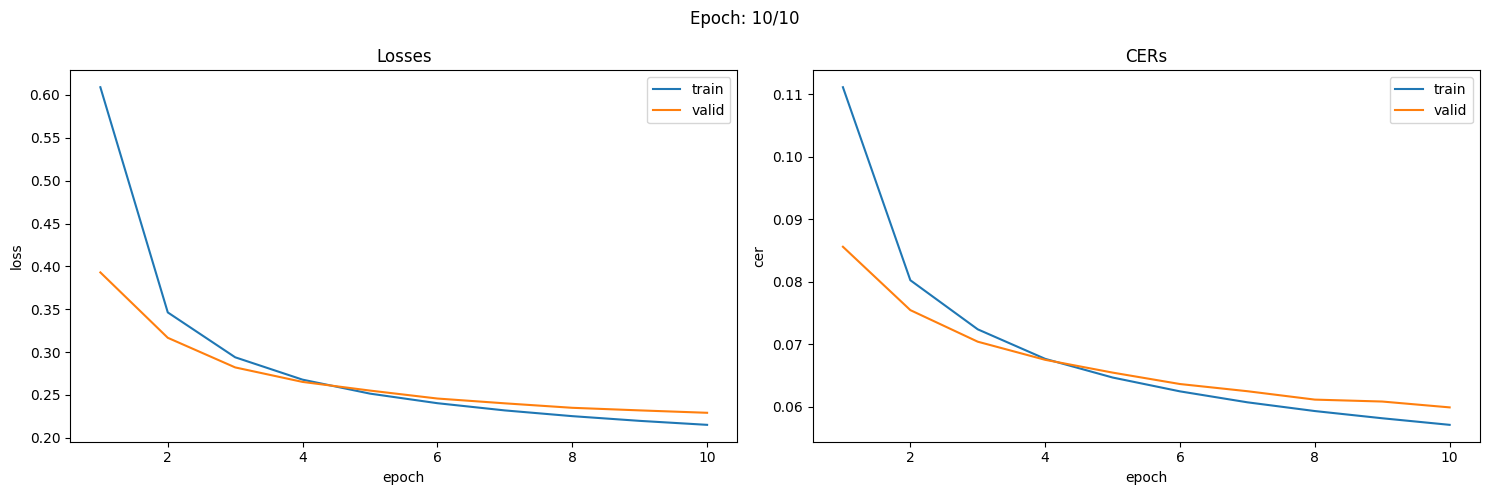

In [16]:
history = fit(model, optimizer, scheduler, criterion, train_loader, valid_loader, vocab, device, epochs, history)

In [17]:
model = model.to('cpu')

In [18]:
@torch.inference_mode()
def inference(model, test_loader, vocab, device):
    model.eval()
    all_pred_texts = []
    for X, misspell in (pbar := tqdm(test_loader, desc='Test Loader', leave=True)):
        misspell = misspell[0]
        X = X.to(device)
        lengths = torch.tensor([len(X[0])])
        output, lengths = model(X, lengths)
        
        pred_indices = output[0].argmax(-1)
        pred_text = vocab.decode(pred_indices.tolist())
        all_pred_texts.append(pred_text)

    return all_pred_texts

In [19]:
%%time

test_preds = inference(model, test_loader, vocab, 'cpu')

Test Loader:   0%|          | 0/2643 [00:00<?, ?it/s]

CPU times: user 4min 1s, sys: 5.65 s, total: 4min 7s
Wall time: 2min 3s


In [20]:
import pandas as pd

df = pd.DataFrame(test_preds)
df = df.reset_index()
df.columns = ["id", "corrected"]
df.to_csv("/kaggle/working/submission.csv", index=False)

print("submission.csv generated!")

submission.csv generated!
